In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from scipy.linalg import qr, pinv
from scipy.linalg import solve_triangular


np.random.seed(42)

# LOESS
Рассмотрим обыкновенную линейную регрессию. Её формула:

$$
y_i = f(x_i) + \epsilon_i,
$$

где

$$
f(x_i) = \beta_0 + \beta_1 \cdot x_i.
$$

Однако рассмотрим данные следующего вида:

In [43]:
x = np.linspace(-15, 15, 300)
y = np.sin(x) + np.random.normal(0, 0.2, 300)

<Axes: >

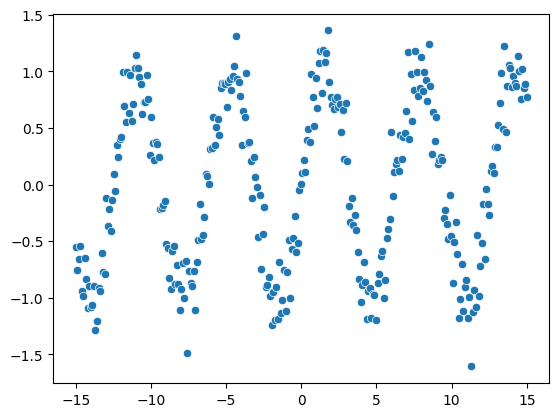

In [44]:
sns.scatterplot(x=x, y=y)

Попробуем обучить модель линейной модели на этих данных

<Axes: >

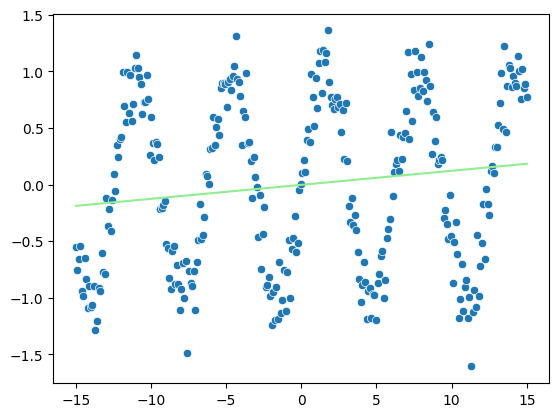

In [45]:
lin = LinearRegression().fit(x.reshape(-1, 1), y)
preds_lin = lin.predict(x.reshape(-1, 1))
sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=preds_lin, color="lightgreen")

Кажется, что линейная модель никак не может выявить зависимость в данных. Одно из возможных решений - полиномиальная регрессия. Как думаете, какая степень полинома понадобится?

<Axes: >

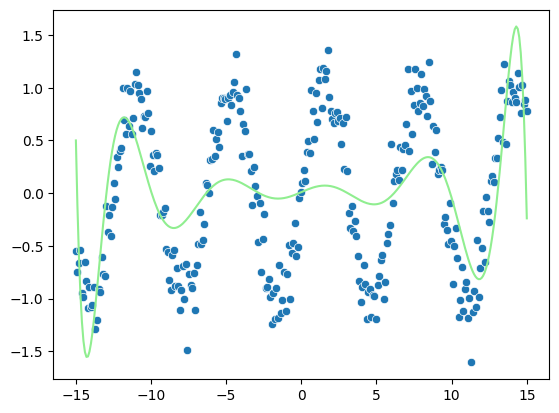

In [46]:
pipe = make_pipeline( PolynomialFeatures(degree=11), LinearRegression())
pipe.fit(x.reshape(-1, 1),y)
preds = pipe.predict(x.reshape(-1, 1))
sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=preds, color="lightgreen")

Кажется, что для таких данных построить единую модель будет чрезвычайно сложно. Как можно решить такую проблему? Одно из решений - каким-то образом взвесить семплы, чтобы семплы ближе к переломам были более важны.

<Axes: >

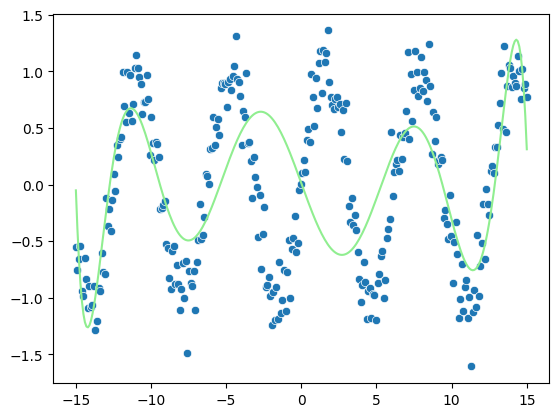

In [47]:
#Обучите с более высокой степенью

pipe = make_pipeline( PolynomialFeatures(degree=11), LinearRegression())
pipe.fit(x.reshape(-1, 1), y,  linearregression__sample_weight=abs(x))
preds = pipe.predict(x.reshape(-1, 1))
sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=preds, color="lightgreen")


Выглядит уже ближе. Однако как бы нам сделать процесс взвешивания автоматическим? Рассмотрим модель взвешенной регрессии.

## Ядровая регрессия Надарая–Уотсона

Рассмотрим непараметрическую постановку $y_i = f(x_i) + \varepsilon_i$, где $f$ не фиксируется заранее конечномерным набором параметров.

**Ядерная регрессия Надарая–Уотсона (NW)** в точке $x$ задаёт оценку $\hat f(x)$ как взвешенное среднее значений $y_i$: вклад $i$-й точки убывает с ростом $|x-x_i|$, а вид этого убывания задаётся **ядром** $K$.

Ядро — это невозрастающая гладкая и ограниченная функция двух точек входа $k(x,x')$, которая задаёт, насколько они «похожи» относительно выбранного понятия расстояния между $x$ и $x'$. В идеале, эта функция должа удовлетворять еще двум свойствам - равенству интеграла единице и симметрии относительно 0. 

В NW используется одномерный вид $K_h(x-x_i)$ по разности между точкой оценки и наблюдением. При этом в разных методах ядро может трактоваться немного по-разному. В нашем случае эта функция задает веса регрессии (среднего).

Используем **трикубическое ядро**. Положим $u_i(x)=|x-x_i|/h$, где h - ширина окна. Тогда
$$
K_h(x-x_i)=\bigl(1-u_i(x)^3\bigr)_+^3\quad\text{при }u_i(x)<1,\qquad 0\ \text{ иначе}.
$$
У такого ядра **компактный носитель**: ненулевой вклад будет получен только при $|x-x_i|<h$.


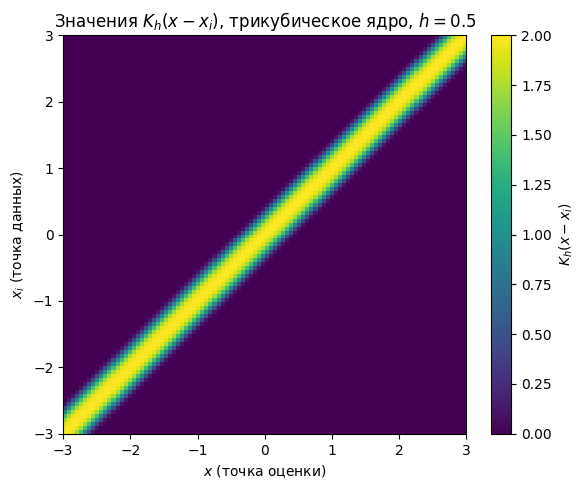

In [48]:
def tricubic_kernel_u(u: np.ndarray) -> np.ndarray:
    u = np.abs(u)
    out = np.zeros_like(u, dtype=float)
    m = u < 1.0
    out[m] = (1 - u[m]**3)**3
    return out


n: int = 100
x_grid = np.linspace(-3.0, 3.0, n)
h: float = 0.5
X_i = x_grid[:, None]
X_j = x_grid[None, :]
diff_signed = (X_j - X_i) / h
K_mat = tricubic_kernel_u(diff_signed) / h

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    K_mat,
    origin="lower",
    extent=(x_grid.min(), x_grid.max(), x_grid.min(), x_grid.max()),
    aspect="auto",
    cmap="viridis",
)
ax.set_xlabel("$x$ (точка оценки)")
ax.set_ylabel("$x_i$ (точка данных)")
ax.set_title(f"Значения $K_h(x-x_i)$, трикубическое ядро, $h={h}$")
fig.colorbar(im, ax=ax, label="$K_h(x-x_i)$")
plt.tight_layout()
plt.show()


Оценка Надарая–Уотсона:

$$
\hat{f}_{\mathrm{NW}}(x)=\frac{\sum_{i=1}^n K_h(x-x_i)\,y_i}{\sum_{i=1}^n K_h(x-x_i)}.
$$

Если положить $w_i(x)=K_h(x-x_i)/\sum_{j=1}^n K_h(x-x_j)$, то $\sum_i w_i(x)=1$ и $\hat{f}_{\mathrm{NW}}(x)=\sum_i w_i(x)\,y_i$.


**Алгоритм NW** для некоторого набора точек $x$ будет иметь вид:

1. Зафиксировать ядро и полосу $h$.
2. Для каждого $x$ вычислить $K_h(x-x_i)$ для всех $i=1,\ldots,n$.
3. Вычислить $\hat f_{\mathrm{NW}}(x)$ по формуле выше.
4. Повторить шаги 2–3 для всех $x$.

Посмотрим, что мы получим для нашей задачи, если используем ядерную регрессию:

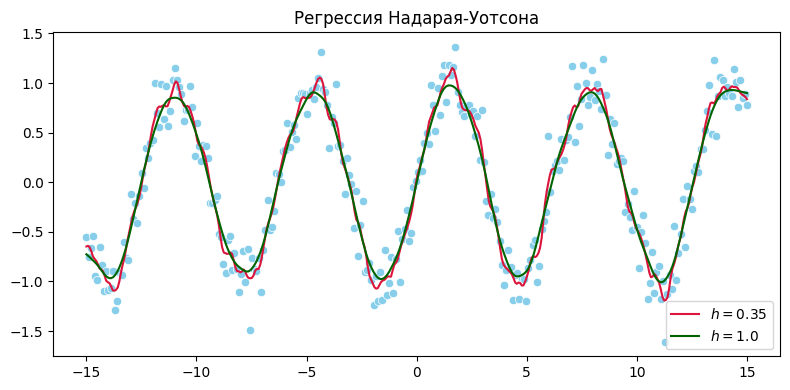

In [49]:
def nw_predict(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_query: np.ndarray,
    h: float,
) -> np.ndarray:
    u = np.abs(x_query[:, None] - x_train[None, :]) / h
    w = tricubic_kernel_u(u)
    s = w.sum(axis=1)
    wy = w @ y_train
    return np.where(s > 0, wy / s, np.nan)


h_narrow = 0.35
h_wide = 1.0
x_query = np.linspace(float(x.min()), float(x.max()), 400)
y_nw_n = nw_predict(x, y, x_query, h_narrow)
y_nw_w = nw_predict(x, y, x_query, h_wide)

fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(x=x, y=y, ax=ax, color="skyblue")
sns.lineplot(x=x_query, y=y_nw_n, ax=ax, color="crimson", label=f"$h={h_narrow}$")
sns.lineplot(x=x_query, y=y_nw_w, ax=ax, color="darkgreen", label=f"$h={h_wide}$")
ax.legend()
ax.set_title(
    "Регрессия Надарая-Уотсона"
)
plt.tight_layout()
plt.show()


При этом мы можем увидеть, что у краёв оценка NW  имеет смещение, так как у крайних семплов нет соседей с обеих сторон.  К выбросам NW также чувствителен: один большой $y_i$ заметно тянет кривую в своей полосе. Рассмотрим это отдельно чуть подробнее:


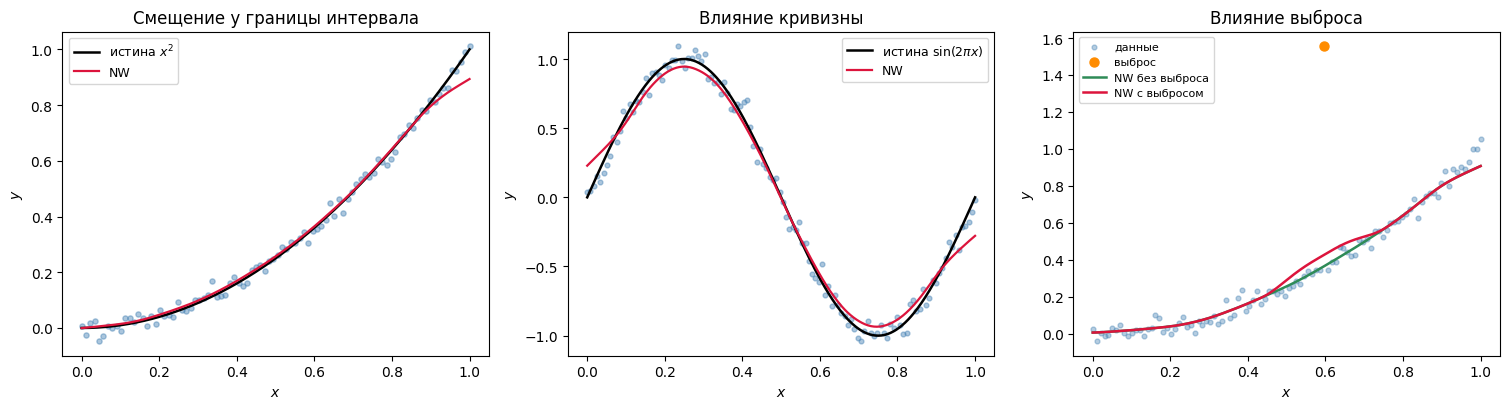

In [50]:
rng = np.random.default_rng(42)
x_edge = np.linspace(0.0, 1.0, 90)
y_edge = x_edge**2 + rng.normal(0.0, 0.025, size=x_edge.shape)
x_q01 = np.linspace(0.0, 1.0, 400)
h_edge: float = 0.18
nw_edge = nw_predict(x_edge, y_edge, x_q01, h_edge)

x_sin = np.linspace(0.0, 1.0, 120)
y_sin = np.sin(2 * np.pi * x_sin) + rng.normal(0.0, 0.06, size=x_sin.shape)
h_sin: float = 0.14
nw_sin = nw_predict(x_sin, y_sin, x_q01, h_sin)

x_out = np.linspace(0.0, 1.0, 100)
y_out_clean = x_out**2 + rng.normal(0.0, 0.03, size=x_out.shape)
outlier_idx = np.argmin(np.abs(x_out - 0.6))
y_out_with = y_out_clean.copy()
y_out_with[outlier_idx] += 1.2
h_out: float = 0.17
nw_out_clean = nw_predict(x_out, y_out_clean, x_q01, h_out)
nw_out_with = nw_predict(x_out, y_out_with, x_q01, h_out)

fig, (axb, axc, axd) = plt.subplots(1, 3, figsize=(15.2, 4.2))
axb.scatter(x_edge, y_edge, s=14, alpha=0.45, color="steelblue")
axb.plot(x_q01, x_q01**2, color="black", linewidth=1.8, label="истина $x^2$")
axb.plot(x_q01, nw_edge, color="crimson", linewidth=1.6, label="NW")
axb.set_title("Смещение у границы интервала")
axb.set_xlabel("$x$")
axb.set_ylabel("$y$")
axb.legend(loc="upper left", fontsize=9)

axc.scatter(x_sin, y_sin, s=12, alpha=0.45, color="steelblue")
axc.plot(x_q01, np.sin(2 * np.pi * x_q01), color="black", linewidth=1.8, label=r"истина $\sin(2\pi x)$")
axc.plot(x_q01, nw_sin, color="crimson", linewidth=1.6, label="NW")
axc.set_title("Влияние кривизны")
axc.set_xlabel("$x$")
axc.set_ylabel("$y$")
axc.legend(loc="upper right", fontsize=9)

axd.scatter(x_out, y_out_with, s=12, alpha=0.4, color="steelblue", label="данные")
axd.scatter(x_out[outlier_idx], y_out_with[outlier_idx], s=42, color="darkorange", zorder=4, label="выброс")
axd.plot(x_q01, nw_out_clean, color="seagreen", linewidth=1.8, label="NW без выброса")
axd.plot(x_q01, nw_out_with, color="crimson", linewidth=1.8, label="NW с выбросом")
axd.set_title("Влияние выброса")
axd.set_xlabel("$x$")
axd.set_ylabel("$y$")
axd.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


Поэтому мы можем перейти к чуть более сложному методу: что если веса в каждой точке будут получаться не через простое взвешиваение, а через полиномиальную (или линейную) регрессию? 

Рассмотрим постановку задачи взвешенной полиномиальной регрессии $\hat{y_i} = (\beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \cdots)$:
$$
\sum_i w_i(x_0)\,\bigl(y_i - (\beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \cdots)\bigr)^2 \rightarrow \min_{\beta}.
$$


1. Обозначим через $x_i$ набор $n$ значений признаков (сейчас для 1 переменной) и пусть $y_i$ представляет соответствующие целевые значения.

2. Найдём ближайшие точки к целевой точке $x_0$. Обозначим это множество $D_0$. (Важно учесть расстояния до них: $d_{i0}$).

3. Найдём самое большое расстояние между этими точками. Обозначим эту величину $\delta(x_0)$.

4. Вычислим весовую функцию $w_i$ для каждого $x_i \in D_0$, используя соотношение

    $$
    w_i(x_0) = W\left(\frac{d_{i0}}{\delta(x_0)}\right),
    $$

    где $W(u)$ некоторое ядро (снова!). Используем трикуб:

    $$
    W(u) =
    \begin{cases}
    (1 - u^3)^3, & 0 \leq u < 1 \\
    0, & \text{иначе.}
    \end{cases}
    $$

5. Оценку $\hat{f}(x_0)$ получают из взвешенных МНК. В матричном виде, с диагональной матрицей весов $W$ и матрицей признаков $X$:

$$
\begin{align}
W X \hat{\beta} &= W y \\
X^{\mathsf T} W X \hat{\beta} &= X^{\mathsf T} W y \\
\hat{\beta} &= (X^{\mathsf T} W X)^{-1} X^{\mathsf T} W y
\end{align}
$$

LOESS сочетает в себе простоту линейной (полиномиальной) регрессии с универсальностью непараметрических методов. При этом метод получается достаточно гибким за счет возможностей выбора степеней полинома, ядра и его параметров.

Так, можно задать ширину пропускания числом соседей, которые будут использоваться для расчётов. Для начала воспользуемся таким способом. 


Реализуем метод локальной регрессии. Это придётся делать в несколько этапов. Так, нам необходимо решить уравнение

$$
W X \hat{\beta} = W y
$$

(эквивалентно нормальным уравнениям $X^{\mathsf T} W X \hat{\beta} = X^{\mathsf T} W y$).

In [51]:
def solve(x, y, W, deg: int = 1):

    A = np.vander(x, N=1+deg) # |  X^2 |X | X^0 ... - we construct polynomial features from x

    # x is horizontal, since we need to transpose it to get solution
    V =  A.T @ W @ A
    Y =  A.T @ W @ y
    Q, R = qr(V)  # make triangular from matrix to get easier solution -> (X^T W)^T X = QR -> final equation: R beta = Q^T * ( X^T W ) y makes
    p = solve_triangular(R, np.matmul(Q.T, Y)) # helps to solve equation with triangular left matrix
    return p


Напишем функцию, задающую нашу полосу пропускания и определяющую, какие точки в неё попали:


In [52]:
def get_span(x: np.array, y: np.array, x_target: float, k: int) -> tuple[np.typing.NDArray, np.typing.NDArray, np.typing.NDArray]:
    """ Returns distances, x in span and y in span.
     x is all the x, x_targte - target x, k - number of neighbours to use
     """
    # get list of distances
    distance = np.abs(x - x_target)
    # get sorted distances and corresponding indices (using, for example, np.sort + np.argsort)
    sorted_dist = np.sort(distance) #
    ind = np.argsort(distance) #

    ind_span = ind[:k]
    # we need to use x-s and y-s later in the code, so get them too
    x_span = x[ind_span]
    y_span = y[ind_span]
    # which distance is the lowest? k -1 or 1?
    delta_0 = sorted_dist[k-1]
    # get normalized distances
    u = distance[ind_span] / delta_0
    return u, x_span, y_span, ind_span

И соберем финальную функцию.

In [53]:
def loess_tricub(x, y, k, deg):

    y_hat = np.zeros(len(x))
    x_space = np.zeros_like(x)

    for i, x_target in enumerate(x):
        # get span
        u, x_span, y_span, _ = get_span(x, y, x_target, k)
        w = (1 - u**3)**3
        # Make W diagonal
        W = np.diag(w)
        p = solve(x_span, y_span, W, deg = deg)
        y_hat[i] = np.polyval(p, x_target)
        x_space[i] = x_target
    return y_hat, x_space


Построим графики предсказаний для разных K.

error =  0.02083766235916928


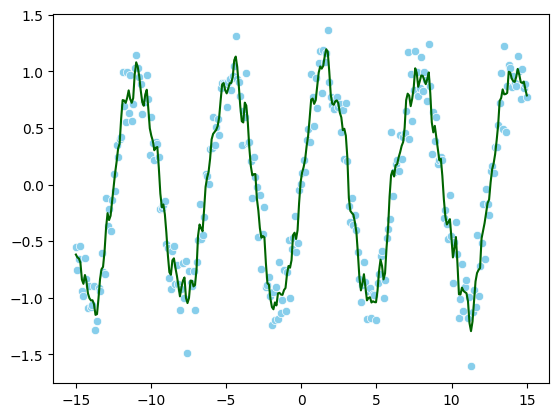

In [54]:
y_pred, x_pred = loess_tricub(x, y, k=5, deg=1)
fig = plt.figure()
sns.scatterplot(x=x, y=y, color ='skyblue')
sns.lineplot(x=x_pred, y=y_pred, color ='darkgreen')
print("error = ", mean_squared_error(y_true=y, y_pred=y_pred))
# make loess regression with small k and plots

error =  0.03758271258545018


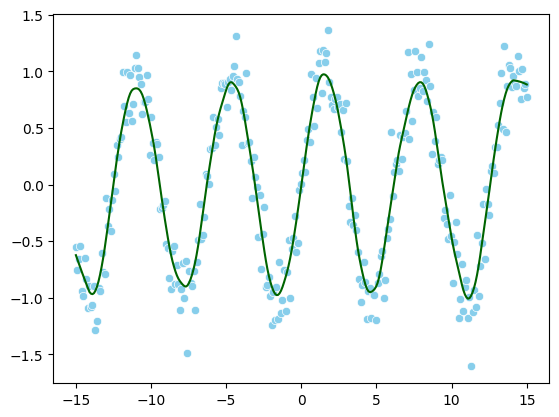

In [55]:
# make loess regression with bigger k and plots
y_pred, x_pred = loess_tricub(x, y, k=20, deg=1)
fig = plt.figure()
sns.scatterplot(x=x, y=y, color ='skyblue')
sns.lineplot(x=x_pred, y=y_pred, color ='darkgreen')
print("error = ", mean_squared_error(y_true=y, y_pred=y_pred))

Чем больше k, тем более сглаженным получается решение. Но можно, например, перейти к бьоле гибком выбору полосы пропускания, которой мы уже пользовались в методе Надарая-Уотсона и использовать пропорцию от размера датасета. Реализуем это.

In [59]:
def get_k_relative(alpha: float, n: int):
    return max(1, int(alpha * n))

def loess_tricub_alpha(x, y, alpha, deg):
    k = get_k_relative(alpha=alpha, n=len(x))
    y_hat = np.zeros(len(x))
    x_space = np.zeros_like(x)

    for i, x_target in enumerate(x):
        u, x_span, y_span, _ = get_span(x, y, x_target, k)
        w = (1 - u**3)**3

        W = np.diag(w)
        p = solve(x_span, y_span, W, deg = deg)
        y_hat[i] = np.polyval(p, x_target)
        x_space[i] = x_target

    return y_hat, x_space


error =  0.5084280660749575


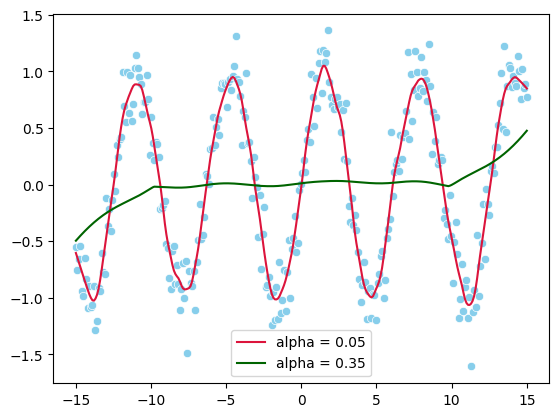

In [60]:
alpha_narrow = 0.05
alpha_wide = 0.35
y_pred, x_pred = loess_tricub_alpha(x, y, alpha=alpha_narrow, deg=1)
fig = plt.figure()
sns.scatterplot(x=x, y=y, color ='skyblue')
sns.lineplot(x=x_pred, y=y_pred, color ='crimson', label=f"alpha = {alpha_narrow}")
y_pred, x_pred = loess_tricub_alpha(x, y, alpha=alpha_wide, deg=1)
sns.lineplot(x=x_pred, y=y_pred, color ='darkgreen', label=f"alpha = {alpha_wide}")
print("error = ", mean_squared_error(y_true=y, y_pred=y_pred))

Можно ли использовать другие функции в качестве весовых? Да, например, воспользуемся колоколообразным (гауссовым) ядром:

$$
w^{(i)} = \exp\left( -\frac{(x^{(i)} - x)^2}{2\tau^2} \right).
$$

Параметр $\tau$ выполняет ту же роль, что у полосы $h$ в блоке про ядерную регрессию NW выше и контролирует, насколько быстро вес обучающего примера падает с увеличением расстояния до точки $x$, и называется параметром *bandwidth*. Вопрос: как меняется форма «колокола» при увеличении $\tau$?

Чем больше тау, тем шире и более пологим становится колокол. Точки дальше от x таргет получают больший вес.

In [61]:
# Make loess function with kernel as parameter

def loess(x, y, kernel, alpha, deg, **kernel_params):
    n = len(x)
    k = max(1, int(alpha * n))
    y_hat = np.zeros(n)
    x_space = np.zeros_like(x)
    
    for i, x_target in enumerate(x):
        distance = np.abs(x - x_target)
        ind = np.argsort(distance)
        ind_span = ind[:k]
        x_span = x[ind_span]
        y_span = y[ind_span]
        delta = distance[ind_span][-1]
        u = distance[ind_span] / delta
        
        if 'tau' in kernel_params:
            w = kernel(u, tau=kernel_params['tau'])
        else:
            w = kernel(u)
        
        W = np.diag(w)
        A = np.vander(x_span, N=1+deg)
        V = A.T @ W @ A
        Y = A.T @ W @ y_span
        Q, R = qr(V)
        p = solve_triangular(R, Q.T @ Y)
        y_hat[i] = np.polyval(p[::-1], x_target)
        x_space[i] = x_target
    
    return x_space, y_hat

Ещё один классический пример — гауссово (RBF) ядро на $\mathbb{R}^p$:
$$
k(x,x')=\sigma^2\exp\left(-\frac{1}{2\ell^2}\|x-x'\|^2\right).
$$
Параметр $\ell$ задаёт горизонтальный масштаб, $\sigma^2$ — вертикальный.

Такие ядра используют при задании ковариаций в гауссовских процессах и в методе опорных векторов (SVM).

Вообще разнообразных ядер достаточно много:

На нормированном расстоянии $u = d/\delta \in [0,1]$ часто используются:

- **трикуб**: $(1-u^3)^3$ при $u<1$;
- **Epanechnikov**: ${3 \over 4} (1-u^2)$;
- **биквадратное** (квадратичное): ${15 \over 16} (1-u^2)^2$;
- **триквадратное** (квадратичное): ${32 \over 33} (1-u^2)^3$;
- **треугольное**:  $(1-|u|)$;
- **равномерное**: $\mathbf{1}_{[0,1]}(u)$;
- **гауссово**: ${1 \over \sqrt{2\pi}} \exp(-{1 \over 2 } u^2)$; параметр $\tau$ задаёт ширину «колокола» (см. график справа).

Ниже слева — кривые нескольких ядер как функций $u$; справа — гауссово $K(d)$ при разных $\tau$. Затем — **сравнение тепловых карт** $K_h(x,x_i)$ на одной сетке и при одном $h$ для трикуба и гаусса: у трикуба носитель компактен, у гаусса — бесконечный хвост.

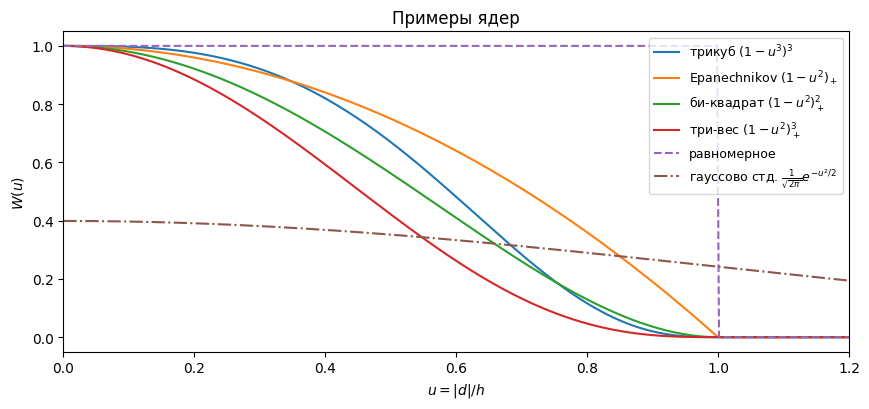

In [62]:
u_grid = np.linspace(0, 1.2, 400)
tricub = np.where((u_grid >= 0) & (u_grid < 1), (1 - u_grid**3) ** 3, 0.0)
epa = np.where((u_grid >= 0) & (u_grid <= 1), np.maximum(0, 1 - u_grid**2), 0.0)
bisq = np.where((u_grid >= 0) & (u_grid <= 1), np.maximum(0, 1 - u_grid**2) ** 2, 0.0)
triw = np.where((u_grid >= 0) & (u_grid <= 1), np.maximum(0, 1 - u_grid**2) ** 3, 0.0)
unif = np.where((u_grid >= 0) & (u_grid <= 1), 1.0, 0.0)
gau_std = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u_grid**2)

fig, ax = plt.subplots(1, 1, figsize=(8.8, 4.2))
ax.plot(u_grid, tricub, label="трикуб $(1-u^3)^3$")
ax.plot(u_grid, epa, label="Epanechnikov $(1-u^2)_+$")
ax.plot(u_grid, bisq, label="би-квадрат $(1-u^2)_+^2$")
ax.plot(u_grid, triw, label="три-вес $(1-u^2)_+^3$")
ax.plot(u_grid, unif, linestyle="--", label="равномерное")
ax.plot(u_grid, gau_std, linestyle="-.", label="гауссово стд. $\\frac{1}{\\sqrt{2\\pi}}e^{-u^2/2}$")
ax.set_xlabel("$u = |d|/h$")
ax.set_ylabel("$W(u)$")
ax.set_title("Примеры ядер")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 1.2)
plt.tight_layout()
plt.show()

Задание: постройте тепловые карты для гауссовского, равномерного и любого другого ядер

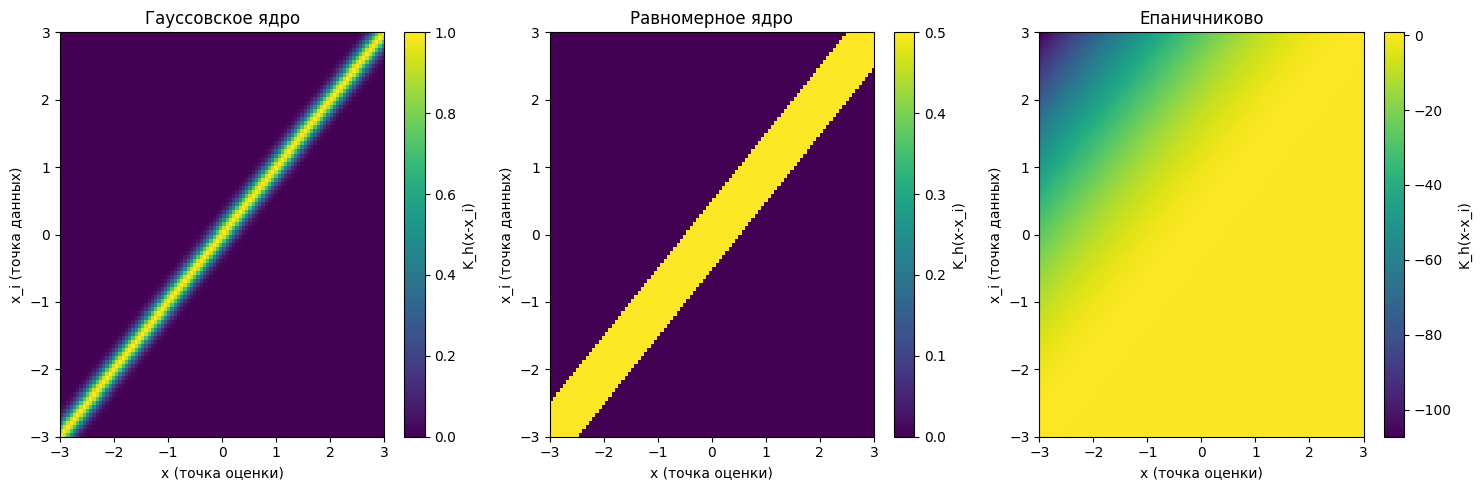

In [90]:
def gaussian_kernel(dist, tau=0.5):
    return np.exp(-(dist**2) / (2 * tau**2))

def epanechnikov_kernel(dist):
    mask = dist < 1
    return (3/4 * (1 - dist**2)) * mask

def uniform_kernel(dist):
    return np.where(np.abs(dist) < 1, 0.5, 0.0)

def triweight_kernel(dist):
    mask = dist < 1
    return ((1 - dist**2)**3) * mask


n = 100
x_grid = np.linspace(-3, 3, n)
h = 0.5
tau = 0.3

X_i = x_grid[:, None]
X_j = x_grid[None, :]
diff = (X_j - X_i) / h

K_gauss = gaussian_kernel(diff, tau=tau)
K_unif = uniform_kernel(diff)
K_epa = epanechnikov_kernel(diff)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

titles = ['Гауссовское ядро', 'Равномерное ядро', 'Епаничниково']
kernels = [K_gauss, K_unif, K_epa]

for ax, K, title in zip(axes, kernels, titles):
    im = ax.imshow(K, origin='lower', 
                   extent=(x_grid.min(), x_grid.max(), x_grid.min(), x_grid.max()),
                   aspect='auto', cmap='viridis')
    ax.set_xlabel('x (точка оценки)')
    ax.set_ylabel('x_i (точка данных)')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label='K_h(x-x_i)')

plt.tight_layout()
plt.show()

In [63]:
def tricub_kernel(dist: np.ndarray) -> np.ndarray:
    abs_dist = np.abs(dist)
    return np.where(abs_dist < 1, (1 - abs_dist**3) ** 3, 0.0)

def bell_kernel(dist: np.ndarray, tau: float) -> np.ndarray:
    return np.exp(-(dist**2) / (2 * tau**2))


error =  0.5084280660749575


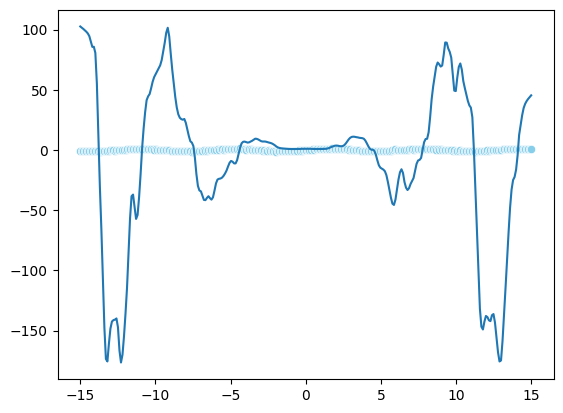

In [64]:
# calculate tricub loess with kernel as parameter

x_est, y_est = loess(x, y, kernel=tricub_kernel, alpha=0.05, deg=1)
sns.lineplot(x=x_est, y=y_est)
sns.scatterplot(x=x, y=y, color ='skyblue')

print("error = ", mean_squared_error(y_true=y, y_pred=y_pred))

error tricub =  0.5084280660749575
error bell =  0.5084280660749575


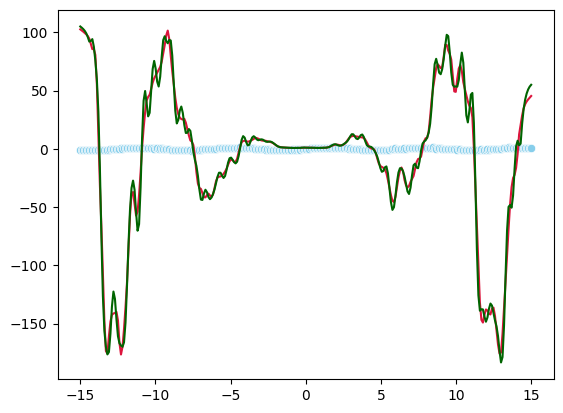

In [65]:
tau = 0.3
#make loess with bell kernel

x_est, y_est = loess(x, y, kernel=tricub_kernel, alpha=0.05, deg=1)
sns.lineplot(x=x_est, y=y_est, color="crimson")
print("error tricub = ", mean_squared_error(y_true=y, y_pred=y_pred))
sns.scatterplot(x=x, y=y, color ='skyblue')
x_est, y_est = loess(x, y, kernel=bell_kernel, alpha=0.05, deg=1, tau=tau)
sns.lineplot(x=x_est, y=y_est, color="darkgreen")
print("error bell = ", mean_squared_error(y_true=y, y_pred=y_pred))

Раз $tau$ регулирует, какой вклад будут давать дальние элементы, чего не было в обычном трикубическом ядре, нужен ли нам теперь параметр $\alpha$?

Нужен, чтоб определить количество соседей

error tricub =  4060.6656638172626
error bell =  3961.09124792646


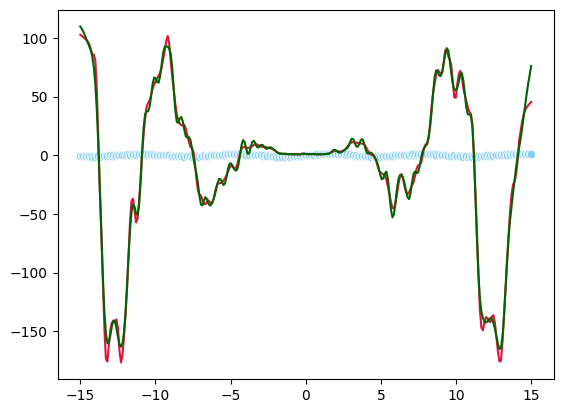

In [66]:
# set a as 1. and find tau which gives similar results
x_est_tricub, y_est_tricub = loess(x, y, kernel=tricub_kernel, alpha=0.05, deg=1)
sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson")
print("error tricub = ", mean_squared_error(y_true=y, y_pred=y_est_tricub))
sns.scatterplot(x=x, y=y, color='skyblue')
tau = 0.01
x_est_bell, y_est_bell = loess(x, y, kernel=bell_kernel, alpha=1, deg=1, tau=tau)
sns.lineplot(x=x_est_bell, y=y_est_bell, color="darkgreen")
print("error bell = ", mean_squared_error(y_true=y, y_pred=y_est_bell))

Если ошибки имеют симметричное распределение (с длинными хвостами) или есть выбросы, мы можем использовать более робастный LOESS.

Определим остатки:

$$
r_i = y_i - f(x_i).
$$

В нашем случае:

tricub tail share (robust z > 3) = 0.11333333333333333
bell tail share (robust z > 3) = 0.11
tricub excess kurtosis = 0.741463586081506
bell excess kurtosis = 0.5817370761714797


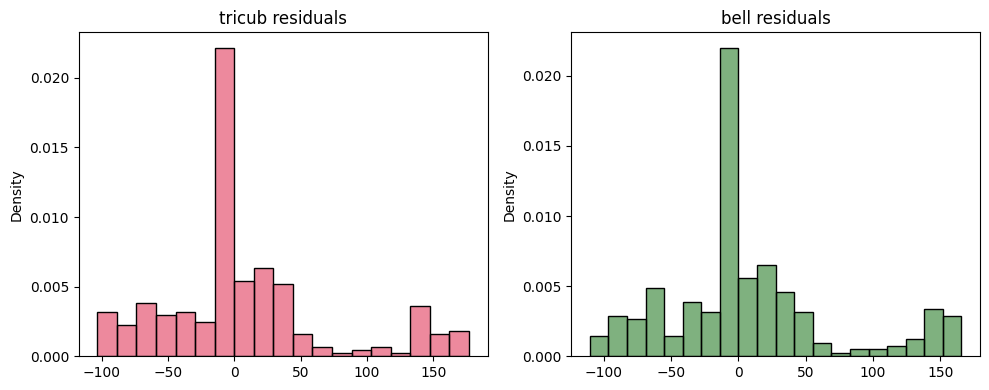

In [67]:

res_tricub = y - y_est_tricub
res_bell = y - y_est_bell

tricub_med = np.median(res_tricub)
tricub_mad = np.median(np.abs(res_tricub - tricub_med)) + 1e-12
tricub_robust_z = np.abs(res_tricub - tricub_med) / (1.4826 * tricub_mad)
tricub_tail_share = np.mean(tricub_robust_z > 3)
tricub_center = res_tricub - np.mean(res_tricub)
tricub_m2 = np.mean(tricub_center**2) + 1e-12
tricub_excess_kurtosis = np.mean(tricub_center**4) / (tricub_m2**2) - 3

bell_med = np.median(res_bell)
bell_mad = np.median(np.abs(res_bell - bell_med)) + 1e-12
bell_robust_z = np.abs(res_bell - bell_med) / (1.4826 * bell_mad)
bell_tail_share = np.mean(bell_robust_z > 3)
bell_center = res_bell - np.mean(res_bell)
bell_m2 = np.mean(bell_center**2) + 1e-12
bell_excess_kurtosis = np.mean(bell_center**4) / (bell_m2**2) - 3

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(res_tricub, stat="density", kde=False, color="crimson", alpha=0.5, ax=axes[0])
axes[0].set_title("tricub residuals")
sns.histplot(res_bell, stat="density", kde=False, color="darkgreen", alpha=0.5, ax=axes[1])
axes[1].set_title("bell residuals")
plt.tight_layout()

print("tricub tail share (robust z > 3) =", tricub_tail_share)
print("bell tail share (robust z > 3) =", bell_tail_share)
print("tricub excess kurtosis =", tricub_excess_kurtosis)
print("bell excess kurtosis =", bell_excess_kurtosis)



Используем базовое ядро, заданное биквадратной функцией (bisquare):

$$
B(u) =
\begin{cases}
(1 - u^2)^2, & 0 \leq u < 1 \\
0, & \text{иначе.}
\end{cases}
$$

Пусть $m(r) = \mathrm{median}(|r|)$. Дополнительные веса тогда:

$$
\gamma_i = B\left(\frac{r_i}{6m}\right).
$$

Финальные веса принимают вид $\tilde{w}_i = \gamma_i\, w_i$.


In [68]:
def bicubic_kernel(dist):
    mask = dist < 1.  
    return ((1 - dist ** 2) ** 2) * mask # create bicubic kernel

def get_robust_weights(y, y_pred):
    residuals = y - y_pred
    s = np.median(np.abs(residuals))
    multiplier = (np.abs(residuals) / (6.0 * s) ) # we clip to preserve final results bounds
    multiplier = bicubic_kernel(multiplier)
    return multiplier

In [69]:
def loess_robust(x, y, kernel, alpha, deg, iterations, **kernel_params):
    k = get_k_relative(alpha=alpha, n=len(x))
    y_pred = np.zeros(len(x))
    x_space = np.zeros_like(x)
    r_weights = np.ones(len(x))
    for iter in range(iterations):
        # make one iteration of loess
        r_weights = get_robust_weights(y, y_pred)
        print(r_weights)
    return x_space, y_pred

Построим данные, у которых действительно будут проблемы:

In [70]:
x = np.linspace(-15, 15, 300)
y = np.sin(x) + np.random.normal(0, 0.2, 300)
y[5:10] -= 0.6
y[45:50] += 1.1
y[-30] += 1.
x[-45:-40] -= 0.1

x[145] += 1.1

x[-89:-80] -= 0.4


In [71]:
x_est_bell , y_est_bell = loess(x, y, kernel=bell_kernel, alpha=0.05, deg=1, tau=0.3)
x_est_tricub , y_est_tricub = loess(x, y, kernel=tricub_kernel, alpha=0.05, deg=1)

Посмотрим, какие результаты мы получили:

tricub tail share (robust z > 3) = 0.12333333333333334
bell tail share (robust z > 3) = 0.13666666666666666
tricub excess kurtosis = 1.18780472087934
bell excess kurtosis = 1.844883124179498


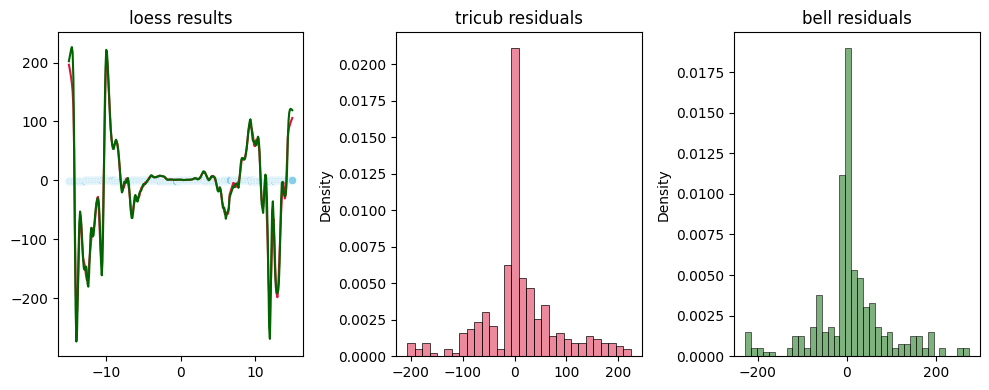

In [72]:

res_tricub = y - y_est_tricub
res_bell = y - y_est_bell

tricub_med = np.median(res_tricub)
tricub_mad = np.median(np.abs(res_tricub - tricub_med)) + 1e-12
tricub_robust_z = np.abs(res_tricub - tricub_med) / (1.4826 * tricub_mad)
tricub_tail_share = np.mean(tricub_robust_z > 3)
tricub_center = res_tricub - np.mean(res_tricub)
tricub_m2 = np.mean(tricub_center**2) + 1e-12
tricub_excess_kurtosis = np.mean(tricub_center**4) / (tricub_m2**2) - 3

bell_med = np.median(res_bell)
bell_mad = np.median(np.abs(res_bell - bell_med)) + 1e-12
bell_robust_z = np.abs(res_bell - bell_med) / (1.4826 * bell_mad)
bell_tail_share = np.mean(bell_robust_z > 3)
bell_center = res_bell - np.mean(res_bell)
bell_m2 = np.mean(bell_center**2) + 1e-12
bell_excess_kurtosis = np.mean(bell_center**4) / (bell_m2**2) - 3
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

sns.scatterplot(x=x, y=y, color='skyblue', ax=axes[0])

sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson", ax=axes[0])
sns.lineplot(x=x_est_bell, y=y_est_bell, color="darkgreen", ax=axes[0])
axes[0].set_title("loess results")
sns.histplot(res_tricub, stat="density", kde=False, color="crimson", alpha=0.5, ax=axes[1])
axes[1].set_title("tricub residuals")
sns.histplot(res_bell, stat="density", kde=False, color="darkgreen", alpha=0.5, ax=axes[2])
axes[2].set_title("bell residuals")
plt.tight_layout()

print("tricub tail share (robust z > 3) =", tricub_tail_share)
print("bell tail share (robust z > 3) =", bell_tail_share)
print("tricub excess kurtosis =", tricub_excess_kurtosis)
print("bell excess kurtosis =", bell_excess_kurtosis)


Здесь уже видно, что есть тяжелые хвосты у остатков, попробуем применить робастную версию LOESS.

[0.92458208 0.92109095 0.95338136 0.94036061 0.90874949 0.75345346
 0.81149826 0.69236728 0.76046202 0.71368534 0.8804363  0.93587655
 0.93146013 0.93754096 0.95945297 0.92807628 0.95881502 0.93984358
 0.96874154 0.96792542 0.9820946  0.99530367 0.98269461 0.99012097
 0.99406958 0.99673711 0.98107755 0.97873931 0.97227113 0.96101479
 0.96630026 0.97708321 0.94162738 0.95417832 0.88253763 0.91801141
 0.9346086  0.90997142 0.87349863 0.91198696 0.92102296 0.87839242
 0.88190543 0.91813941 0.92336147 0.58477607 0.71692558 0.73377527
 0.71208509 0.7040752  0.95993188 0.93820716 0.96881309 0.99428333
 0.99730916 0.99761691 0.99974283 0.99533714 0.99637732 0.97098005
 0.98773342 0.99481634 0.95563787 0.95910301 0.95739851 0.9103154
 0.92368316 0.90685444 0.90290391 0.85803841 0.89055795 0.90863375
 0.9431635  0.92883879 0.96773758 0.86928398 0.94219568 0.92748131
 0.98673094 0.91407714 0.92666313 0.94793187 0.90967827 0.9730843
 0.97811683 0.99714897 0.9999557  0.98273665 0.98946511 0.998936

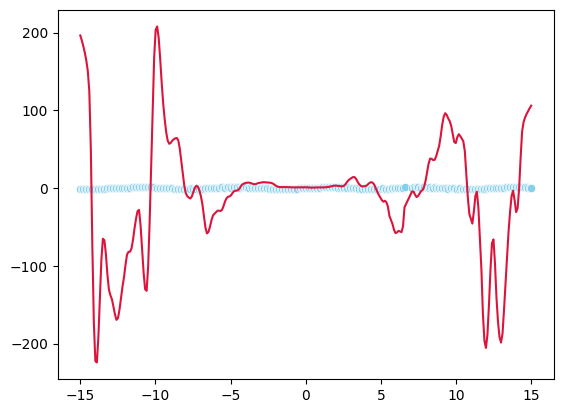

In [73]:
tau = 0.4

x_est, y_est = loess_robust(x, y, kernel=bell_kernel, alpha=0.05, deg=1, iterations=5, tau=tau)
sns.lineplot(x=x_est, y=y_est, color="magenta")
sns.lineplot(x=x_est_tricub, y=y_est_tricub, color="crimson")

sns.scatterplot(x=x, y=y, color ='skyblue')

print("error = ", mean_squared_error(y_true=y, y_pred=y_est))

Задание: попробуйте другие ядра и постройте loess для разных данных с ними. Для каких особенностей данных подходят разные ядра?

In [ ]:
def epanechnikov_kernel(dist):
    mask = dist < 1
    return (3/4 * (1 - dist**2)) * mask

def bisquare_kernel(dist):
    mask = dist < 1
    return ((1 - dist**2)**2) * mask

def triweight_kernel(dist):
    mask = dist < 1
    return ((1 - dist**2)**3) * mask

Трикуб - если нет выбросов
Биквадрат - есть выбросы
Равномерное - нужно быстрое обучение
Гауссово - нужна гладкость

Рассмотрим и уже знакомую нам задачу предсказания стоимости.

In [77]:
data_path = "C:/Users/Lada/Documents/ml"
data = pd.read_csv(f"{data_path}/realestate.txt", sep="\t")

data = data[["SalePrice", "SqFeet", "Lot"]]
data = np.log(data)
X_train, X_test, y_train, y_test = train_test_split(data[["SqFeet"]], data["SalePrice"])

model = LinearRegression().fit(X_train, y_train)
preds = model.predict(X_train)
loess_x, loess_y = loess_robust(X_train.values.astype(float).ravel(), y_train.values.astype(float).ravel(), kernel=bell_kernel, alpha=0.05, deg=1, iterations=5, tau=tau)
loess_x_naive , loess_y_naive = loess(X_train.values.astype(float).ravel(), y_train.values.astype(float).ravel(), kernel=bell_kernel, alpha=0.05, deg=1, tau=tau)


[0.92737318 0.94711265 0.95008219 0.93493784 0.94294473 0.95007955
 0.9229291  0.94854924 0.94021242 0.93994131 0.94248044 0.94489609
 0.94426921 0.93302714 0.94960983 0.95354356 0.94028242 0.94955822
 0.935979   0.92986102 0.95539595 0.92693164 0.94854924 0.94806059
 0.91709112 0.94165151 0.95029141 0.94455972 0.94468531 0.92032566
 0.95139195 0.93302714 0.92440633 0.93826377 0.94830364 0.92890041
 0.92771459 0.95229102 0.9500901  0.94302297 0.94909878 0.93762556
 0.94674386 0.95007955 0.92201027 0.94559199 0.92380202 0.93994131
 0.94966155 0.94286673 0.93891865 0.94981742 0.92560949 0.92300108
 0.9500901  0.93775191 0.96140911 0.93858907 0.95996704 0.91637341
 0.95018524 0.94758187 0.94532327 0.94620118 0.95061286 0.94904829
 0.95115876 0.92637448 0.95252434 0.92592893 0.94936313 0.93583182
 0.935511   0.94672557 0.95007955 0.94183745 0.95299829 0.94349782
 0.95061286 0.95230263 0.94414576 0.9311746  0.94642579 0.94002095
 0.94357707 0.91458901 0.95217524 0.94310147 0.94414576 0.9473

--
--
Linear Regression error:  0.05356445325337977
loess error =  10.537060555271397


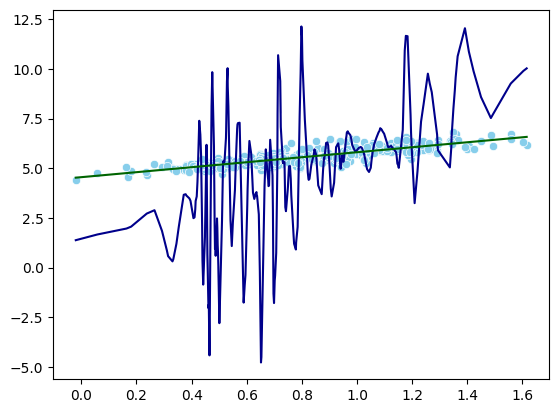

In [78]:
tau = 0.4

print('--')
sns.lineplot(x=loess_x, y=loess_y , color="crimson")
print('--')
sns.lineplot(x=loess_x_naive, y= loess_y_naive , color ='darkblue')
sns.lineplot(x=X_train.values.astype(float).ravel(), y= preds.ravel() , color ='darkgreen')
sns.scatterplot(x=X_train.values.astype(float).ravel(), y=y_train.values.astype(float).ravel() , color ='skyblue')
print("Linear Regression error: ", mean_squared_error(y_true=y_train.values.astype(float).ravel(), y_pred=preds))
print("loess error = ", mean_squared_error(y_true=y_train.values.astype(float).ravel(), y_pred=loess_y_naive))

## KDE

В LOESS ядро задаёт веса точек при локальной регрессии. В **ядерной оценке плотности (KDE)** ядро задаёт форму вклада каждой наблюдаемой точки в оценку **плотности** $f(x)$ по выборке $X_1,\ldots,X_n$:

$\hat{f}(x)=\frac{1}{nh}\sum_{i=1}^{n} K\left(\frac{x-X_i}{h}\right)$. 

В `sklearn.neighbors.KernelDensity` доступно несколько видов ядер, см. [документацию](https://scikit-learn.org/stable/modules/density.html).  При этом KDE реализовано и в skipy со statsmodels, причем вы можете уыидеть, что они содержат методы для поиска наилучших параметров.

Построим KDE для остатков линейной регрессии на обучающей выборке, чтобы связать оценку плотности с уже построенной линейной моделью.

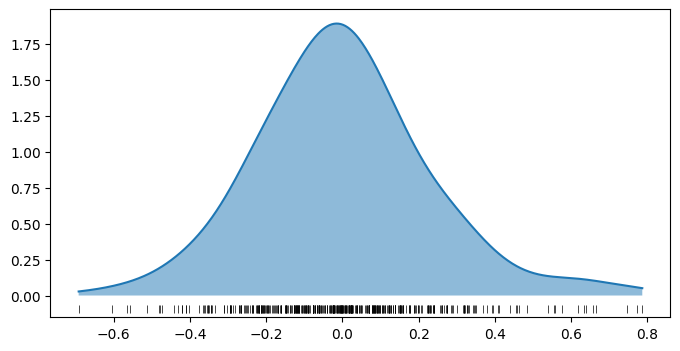

In [79]:
from sklearn.neighbors import KernelDensity

residuals = y_train.values.astype(float).ravel() - preds.ravel()
n = len(residuals)
bw = 1.06 * residuals.std(ddof=1) * (n ** (-0.2))
x_d = np.linspace(residuals.min(), residuals.max(), 500)
kde = KernelDensity(bandwidth=bw, kernel="gaussian")
kde.fit(residuals[:, None])
density = np.exp(kde.score_samples(x_d[:, None]))
fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(x_d, density, alpha=0.5)
ax.plot(x_d, density)
ax.plot(residuals, np.full_like(residuals, -density.max() * 0.05), "|k", markeredgewidth=0.5)
ax.set_ylim(bottom=-density.max() * 0.08)
plt.show()

Рассмотрим, возможно, более интересную задачу - попробуем отрисовать ареалы двух видов животных - ленивцев и лесных хомячков.

In [80]:
from sklearn.datasets import fetch_species_distributions

data = fetch_species_distributions()

# Get matrices/arrays of species IDs and locations
latlon = np.vstack([data.train['dd lat'],
                    data.train['dd long']]).T
species = np.array([d.decode('ascii').startswith('micro')
                    for d in data.train['species']], dtype='int')

c:\Users\Lada\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\datasets\_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976075
  warnings.warn(f"Retry downloading from url: {remote.url}")


In [96]:
#!pip install basemap

In [81]:
y_min, y_max = data.train['dd lat'].min(), data.train['dd lat'].max()
x_min, x_max = data.train['dd long'].min(), data.train['dd long'].max()

In [83]:
def construct_grids(batch):
    # x,y coordinates for corner cells
    xmin = batch.x_left_lower_corner + batch.grid_size
    xmax = xmin  + batch.Nx * batch.grid_size
    ymin = batch.y_left_lower_corner + batch.grid_size
    ymax = ymin + batch.Ny * batch.grid_size

    # x coordinates of the grid cells
    xgrid = np.arange(xmin, xmax, batch.grid_size)
    # y coordinates of the grid cells
    ygrid = np.arange(ymin, ymax, batch.grid_size)

    return (xgrid, ygrid)

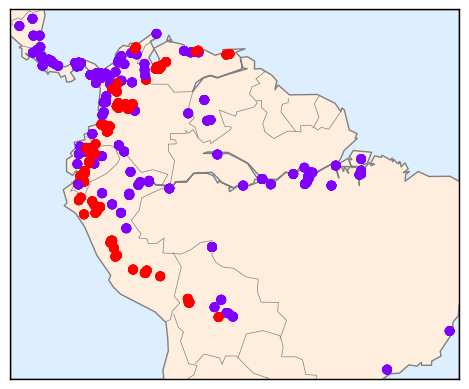

In [87]:
from mpl_toolkits.basemap import Basemap

# plot coastlines with basemap
m = Basemap(projection='cyl', resolution='c',
            llcrnrlat=y_min - 1, urcrnrlat=y_max + 1,
            llcrnrlon=x_min -1, urcrnrlon=x_max + 1)
m.drawmapboundary(fill_color='#DDEEFF')
m.fillcontinents(color='#FFEEDD')
m.drawcoastlines(color='gray', zorder=2)
m.drawcountries(color='gray', zorder=2)

# plot locations
m.scatter(latlon[:, 1], latlon[:, 0], zorder=3,
          c=species, cmap='rainbow', latlon=True);

К сожалению, это не дает хорошего представления о плотности вида, поскольку точки ареала вида могут перекрываться.

Давайте воспользуемся ядерной оценкой плотности, чтобы показать это распределение более понятным способом: как плавное указание плотности на карте. Поскольку система координат здесь лежит на сферической поверхности, а не на плоской плоскости, мы будем использовать метрику расстояния haversinus, которая будет правильно представлять расстояния на искривленной поверхности.


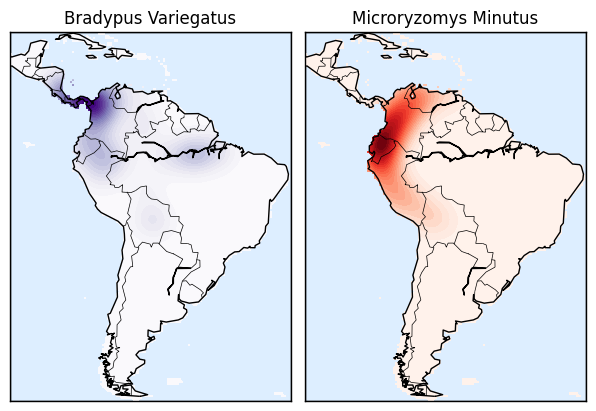

In [88]:
# Set up the data grid for the contour plot

xgrid, ygrid = construct_grids(data)

X, Y = np.meshgrid(xgrid[::5], ygrid[::5][::-1])

land_reference = data.coverages[6][::5, ::5]
land_mask = (land_reference > -9999).ravel()
xy = np.vstack([Y.ravel(), X.ravel()]).T
xy = np.radians(xy[land_mask])

# Create two side-by-side plots
fig, ax = plt.subplots(1, 2)
fig.subplots_adjust(left=0.05, right=0.95, wspace=0.05)
species_names = ['Bradypus Variegatus', 'Microryzomys Minutus']
cmaps = ['Purples', 'Reds']

for i, axi in enumerate(ax):
    axi.set_title(species_names[i])

    # plot coastlines with basemap
    m = Basemap(projection='cyl', llcrnrlat=Y.min(),
                urcrnrlat=Y.max(), llcrnrlon=X.min(),
                urcrnrlon=X.max(), resolution='c', ax=axi)
    m.drawmapboundary(fill_color='#DDEEFF')
    m.drawcoastlines()
    m.drawcountries()

    # construct a spherical kernel density estimate of the distribution
    # use metric='haversine'
    kde = KernelDensity(bandwidth=0.05, kernel="gaussian", metric='haversine') #
    # fit kde, don't forget to convert coords to radians
    kde.fit(np.radians(latlon[species == i]))

    # evaluate only on the land: -9999 indicates ocean
    Z = np.full(land_mask.shape[0], -9999.0)
    Z[land_mask] = np.exp(kde.score_samples(xy)) # exp of kde result
    Z = Z.reshape(X.shape)

    # plot contours of the density
    levels = np.linspace(0, Z.max(), 25)
    axi.contourf(X, Y, Z, levels=levels, cmap=cmaps[i])

Мы видим, что география видов действительно отличается, при этом можно видеть, где сконцентрировано больше всего особей. Так, даже сейчас мы можем попробовать вывести какие-то правила определеняи видов, и это без обучения!

Задание: напищите функцию KDE вручную, опробуйте на каком-нибудь датасете.

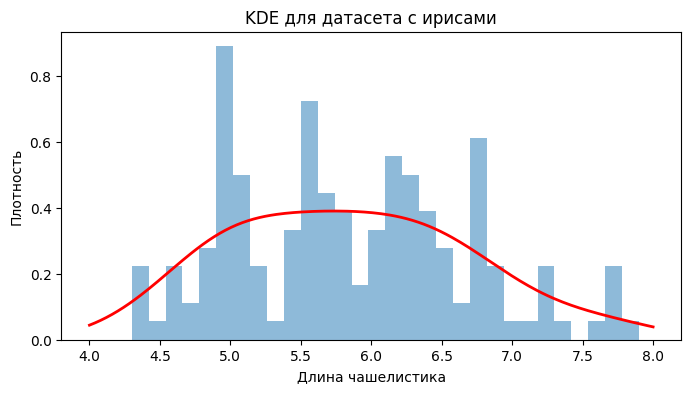

In [95]:
from sklearn.datasets import load_iris

def kde(x, data, h):
    n = len(data)
    result = np.zeros_like(x)
    for i, xi in enumerate(x):
        u = (xi - data) / h
        kernel = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)
        result[i] = np.mean(kernel) / h
    return result

iris = load_iris()
data = iris.data[:, 0]

x_grid = np.linspace(4, 8, 200)
h = 0.4
density = kde(x_grid, data, h)

plt.figure(figsize=(8, 4))
plt.hist(data, bins=30, density=True, alpha=0.5)
plt.plot(x_grid, density, 'r-', linewidth=2)
plt.xlabel('Длина чашелистика')
plt.ylabel('Плотность')
plt.title('KDE для датасета с ирисами')
plt.show()